# MLP를 Top-Down으로 이해하기
## 비선형 분류 문제에서 시작해, 한 개의 숫자 계산 → 역전파 → 실제 데이터 학습까지

이 자료는 제공된 다음 실습 자료의 흐름과 용어를 기반으로 재구성한 초심자용 학습서임.

- **간단한 Perceptron 구현**: `make_moons`, `Tensor`, `autograd`, `nn.Module`, `DataLoader`, optimizer, binary cross entropy, 결정 경계
- **MLP 구현 실습**: `load_digits`, 3-layer MLP, `ReLU`, `Dropout`, `CrossEntropyLoss`, `Adam`, `train()/eval()`, Early Stopping
- **신경망과 MLP 쉬운 자료**: 선형분류기 → XOR/비선형 문제 → 함수 중첩과 활성화 함수 → PyTorch → MLP

자료에서 직접 설명되지 않은 세부 수식 유도와 시각화는 **추가 해설**로 표시함.

---

## 학습 전략: 먼저 “왜 MLP가 필요한가?”를 본 뒤 내부로 내려감

```text
[최종 문제]
곡선 모양으로 섞인 두 클래스를 어떻게 분류할까?
        ↓
[비교]
Perceptron은 직선 하나만 만들 수 있음
        ↓
[해결 아이디어]
여러 Linear + 비선형 활성화 함수
        ↓
[MLP]
Linear → ReLU → Linear → ReLU → Linear
        ↓
[한 샘플 내부 계산]
가중합 → 활성화 → logit → 확률 → loss
        ↓
[학습]
loss.backward() → gradient → optimizer.step()
        ↓
[배치/데이터셋]
DataLoader → 반복 학습
        ↓
[실제 문제]
8×8 손글씨 숫자 0~9 분류
```

### 최종 학습 목표

1. Perceptron과 MLP의 구조 차이를 **결정 경계** 관점에서 설명 가능
2. `Linear` 한 층에서 계산되는 `Wx+b`를 숫자로 직접 계산 가능
3. ReLU가 왜 필요한지 **비선형성** 관점에서 설명 가능
4. 이진 분류의 `logit → sigmoid → BCE loss` 흐름 이해
5. `loss.backward()`가 어떤 미분값을 계산하는지 단일 샘플에서 추적 가능
6. `DataLoader → forward → loss → backward → optimizer.step()` 학습 루프 이해
7. `load_digits` 다중 클래스 문제에서 `CrossEntropyLoss`와 `argmax` 사용 이유 이해

In [1]:
# 0. 환경 준비
import math
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


pd.set_option("display.precision", 4)

print("PyTorch:", torch.__version__)
print("Device :", DEVICE)

PyTorch: 2.10.0+cpu
Device : cpu


# Part 1. 최종 문제부터 보기 — 왜 Perceptron으로 부족한가?

제공 자료의 Perceptron 과제는 `make_moons`를 사용함. 두 클래스가 초승달처럼 휘어 있기 때문에 **선형 결정 경계 하나만으로 완벽하게 분리하기 어려운 데이터**임.

이 데이터가 좋은 이유:

- Feature가 2개라서 좌표평면에 직접 표시 가능
- 클래스가 2개라서 분류 구조가 단순함
- 비선형 경계가 필요하므로 **Perceptron → MLP**의 필요성을 눈으로 확인 가능

먼저 데이터를 보고, “어떤 모양의 경계가 필요한가?”부터 판단함.

   feature_1  feature_2  class
0     0.5810     1.0143      0
1     0.6961    -0.4370      1
2     1.6490     0.0736      1
3     0.8674     0.6769      0
4    -0.3161     0.7105      0

클래스 개수
class
0    300
1    300
Name: count, dtype: int64


/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

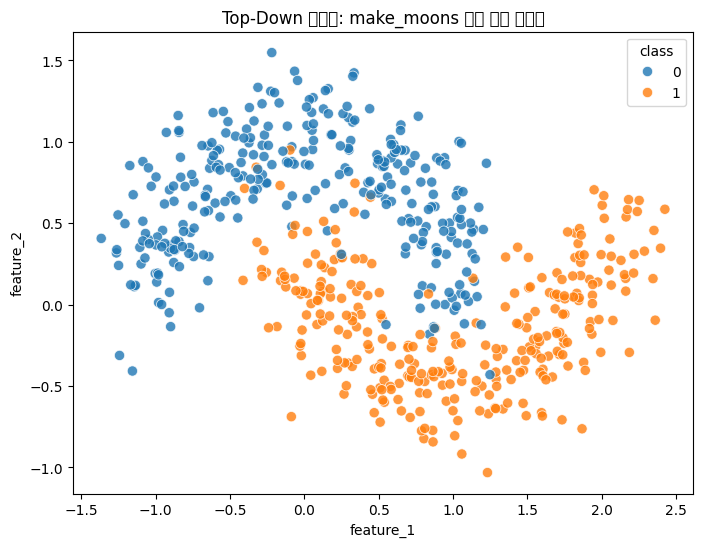

In [2]:
# 1. make_moons 생성
X, y = make_moons(n_samples=600, noise=0.20, random_state=SEED)
moons_df = pd.DataFrame(X, columns=["feature_1", "feature_2"])
moons_df["class"] = y

print(moons_df.head())
print("\n클래스 개수")
print(moons_df["class"].value_counts().sort_index())

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=moons_df, x="feature_1", y="feature_2",
    hue="class", s=55, alpha=0.8
)
plt.title("Top-Down 출발점: make_moons 이진 분류 데이터")
plt.show()

## 관찰해야 할 것

점의 색을 구분하는 **직선 하나**를 상상해보면 완벽하게 나눌 수 없음.

Perceptron의 핵심 계산은 다음과 같음.

\[
z = w_1x_1+w_2x_2+b
\]

그리고 \(z=0\)인 위치가 결정 경계임.

\[
w_1x_1+w_2x_2+b=0
\]

Feature가 2개라면 이 식은 **직선**임. 즉 단일 Perceptron은 직선 하나로 공간을 나눔.

MLP가 필요한 핵심 이유:

> `Linear`만 여러 개 겹치면 결국 하나의 Linear와 동일한 종류의 변환이 됨. 중간에 `ReLU` 같은 **비선형 함수**가 들어가야 꺾이고 휘어진 복잡한 경계를 표현 가능함.

# Part 2. MLP 전체 구조를 먼저 본 뒤 한 층씩 분해하기

이번 이진 분류 모델:

```text
입력 x=(x1, x2)
   ↓
Linear(2 → 8)
   ↓
ReLU
   ↓
Linear(8 → 8)
   ↓
ReLU
   ↓
Linear(8 → 1)
   ↓
logit z
   ↓
Sigmoid
   ↓
P(class=1)
```

PyTorch에서는 학습 안정성을 위해 보통 마지막 `Sigmoid`를 모델 안에 직접 넣지 않고
`BCEWithLogitsLoss`를 사용함.

즉:

```text
모델 출력 = logit
BCEWithLogitsLoss(logit, y)
    └ 내부적으로 sigmoid + binary cross entropy 수행
```

이 방식이 큰 양수/음수 logit에서도 수치적으로 더 안정적임. **추가 해설**임.

In [3]:
# 2. 구조를 코드로 먼저 확인
class MoonMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

model_preview = MoonMLP()
print(model_preview)

dummy = torch.tensor([[0.2, -0.5], [1.0, 0.3]], dtype=torch.float32)
print("\n입력 shape :", dummy.shape)
print("출력 shape :", model_preview(dummy).shape)

MoonMLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)

입력 shape : torch.Size([2, 2])
출력 shape : torch.Size([2])


## Shape를 읽는 법

`Linear(2, 8)`은 “데이터 1개가 가진 Feature 2개를 새로운 값 8개로 변환”함.

배치가 32개라면:

\[
(32,2)\rightarrow(32,8)
\]

다음 `Linear(8,8)`:

\[
(32,8)\rightarrow(32,8)
\]

마지막 `Linear(8,1)`:

\[
(32,8)\rightarrow(32,1)
\]

여기서 8은 “정답 클래스 8개”가 아님. **은닉 표현(hidden representation)의 차원 수**임.

은닉 뉴런들은 원래 Feature를 조합하여 새로운 특징을 만드는 계산 노드로 이해하면 됨.

# Part 3. 가장 작은 MLP 하나를 손으로 계산하기

학습 전체를 이해하기 전에 **샘플 1개**의 계산을 숫자로 끝까지 따라감.

구조를 의도적으로 작게 설정함.

```text
입력 2개 → 은닉 뉴런 3개 → 출력 1개
```

입력:

\[
x=
\begin{bmatrix}
0.5\\
-1.0
\end{bmatrix}
\]

첫 번째 층:

\[
z^{(1)}=W^{(1)}x+b^{(1)}
\]

활성화:

\[
a^{(1)}=\mathrm{ReLU}(z^{(1)})
\]

출력층:

\[
z^{(2)}=W^{(2)}a^{(1)}+b^{(2)}
\]

확률:

\[
p=\sigma(z^{(2)})=\frac{1}{1+e^{-z^{(2)}}}
\]

In [4]:
# 3. 직접 계산할 작은 MLP의 고정 값
x = np.array([0.5, -1.0])
y_true = 1.0

W1 = np.array([
    [ 0.8, -0.4],
    [ 0.3,  0.9],
    [-0.5,  0.2]
])
b1 = np.array([0.1, -0.2, 0.05])

W2 = np.array([1.2, -0.7, 0.5])
b2 = -0.1

z1 = W1 @ x + b1
a1 = np.maximum(0, z1)
z2 = W2 @ a1 + b2
p = 1 / (1 + np.exp(-z2))
loss = -(y_true*np.log(p) + (1-y_true)*np.log(1-p))

calc = pd.DataFrame({
    "뉴런": ["h1", "h2", "h3"],
    "가중합 z1": z1,
    "ReLU 후 a1": a1
})
display(calc)

print(f"출력 logit z2 = {z2:.6f}")
print(f"sigmoid 확률 p = {p:.6f}")
print(f"BCE loss       = {loss:.6f}")

,뉴런,가중합 z1,ReLU 후 a1
0,h1,0.90,0.9
1,h2,-0.95,0.0
2,h3,-0.40,0.0


출력 logit z2 = 0.980000
sigmoid 확률 p = 0.727108
BCE loss       = 0.318680


## 각 숫자의 의미

### 1) \(W^{(1)}x\)

한 은닉 뉴런이 입력 Feature 2개를 **가중합**함.

예를 들어 첫 번째 뉴런:

\[
z_1^{(1)}
=0.8(0.5)+(-0.4)(-1.0)+0.1
\]

- `0.8`: 첫 번째 Feature의 영향
- `-0.4`: 두 번째 Feature의 영향
- `0.1`: bias
- 결과 \(z\): 활성화 함수에 들어가기 전의 원시 점수

### 2) ReLU

\[
\mathrm{ReLU}(z)=\max(0,z)
\]

음수는 0으로 버리고 양수는 유지함.

여기서 중요한 점은 단순한 “음수 제거”가 아니라 **비선형 변환**이라는 사실임.

중간에 ReLU가 없으면:

\[
W_2(W_1x+b_1)+b_2
\]

를 전개하여 다시:

\[
W'x+b'
\]

형태로 합칠 수 있음. 결국 직선 경계로 되돌아감.

### 3) logit

마지막 Linear 출력 \(z^{(2)}\)는 아직 확률이 아님.

- 큰 양수: class 1 쪽 강한 증거
- 큰 음수: class 0 쪽 강한 증거
- 0 근처: 애매함

### 4) sigmoid

logit을 0~1 사이 값으로 바꿈.

\[
\sigma(z)=\frac{1}{1+e^{-z}}
\]

확률처럼 해석 가능한 값을 얻음.

### 5) BCE

정답이 1일 때:

\[
L=-\log(p)
\]

모델이 정답 1에 높은 확률을 주면 loss가 작아짐.

/tmp/ipykernel_711/30039145.py:22: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_711/30039145.py:22: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


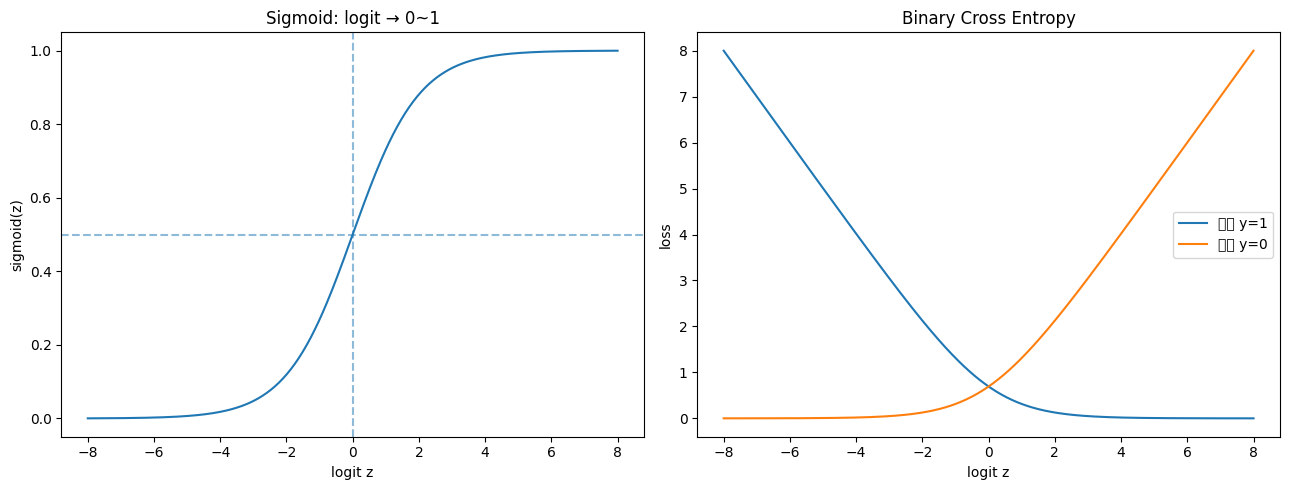

In [5]:
# 4. sigmoid와 BCE의 의미를 시각화
z_grid = np.linspace(-8, 8, 400)
sigmoid = 1 / (1 + np.exp(-z_grid))
loss_y1 = -np.log(np.clip(sigmoid, 1e-12, 1))
loss_y0 = -np.log(np.clip(1 - sigmoid, 1e-12, 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.lineplot(x=z_grid, y=sigmoid, ax=axes[0])
axes[0].axhline(0.5, linestyle="--", alpha=0.5)
axes[0].axvline(0, linestyle="--", alpha=0.5)
axes[0].set_title("Sigmoid: logit → 0~1")
axes[0].set_xlabel("logit z")
axes[0].set_ylabel("sigmoid(z)")

sns.lineplot(x=z_grid, y=loss_y1, label="정답 y=1", ax=axes[1])
sns.lineplot(x=z_grid, y=loss_y0, label="정답 y=0", ax=axes[1])
axes[1].set_title("Binary Cross Entropy")
axes[1].set_xlabel("logit z")
axes[1].set_ylabel("loss")

plt.tight_layout()
plt.show()

# Part 4. Backpropagation — “틀렸으니 어느 가중치를 얼마나 바꿀까?”

제공 자료에서는 `autograd`가 순전파 연산을 추적하고 `.backward()` 호출 시 chain rule을 이용해 기울기를 계산한다고 설명함.

여기서는 그 기울기가 실제로 무엇인지 작은 모델로 확인함.

---

## 출력층에서 시작

Sigmoid + BCE 조합에서는 출력 logit에 대한 미분이 매우 단순해짐.

\[
\frac{\partial L}{\partial z^{(2)}}=p-y
\]

이를 \(\delta^{(2)}\)라고 둠.

\[
\delta^{(2)}=p-y
\]

출력층 가중치:

\[
\frac{\partial L}{\partial W^{(2)}}=
\delta^{(2)}a^{(1)}
\]

출력층 bias:

\[
\frac{\partial L}{\partial b^{(2)}}=
\delta^{(2)}
\]

---

## 은닉층으로 전달

\[
\delta^{(1)}
=
(W^{(2)})^T\delta^{(2)}
\odot
\mathrm{ReLU}'(z^{(1)})
\]

여기서 \(\odot\)는 원소별 곱임.

ReLU 미분:

\[
\mathrm{ReLU}'(z)=
\begin{cases}
1 & z>0\\
0 & z\le 0
\end{cases}
\]

즉 ReLU에서 0이 된 뉴런은 이번 샘플의 역전파에서도 gradient가 0이 될 수 있음.

첫 층:

\[
\frac{\partial L}{\partial W^{(1)}}=
\delta^{(1)}x^T
\]

이 식 때문에 각 입력값 \(x\)가 가중치 업데이트 크기에 직접 영향을 줌.

In [6]:
# 5. 위의 숫자로 gradient를 손 계산
delta2 = p - y_true
dW2 = delta2 * a1
db2 = delta2

relu_grad = (z1 > 0).astype(float)
delta1 = (W2 * delta2) * relu_grad
dW1 = np.outer(delta1, x)
db1 = delta1

print("delta2 =", delta2)
print("\ndW2 =", dW2)
print("db2  =", db2)
print("\nReLU' =", relu_grad)
print("delta1 =", delta1)
print("\ndW1 =")
print(dW1)
print("\ndb1 =", db1)

delta2 = -0.27289178365887046

dW2 = [-0.24560261 -0.         -0.        ]
db2  = -0.27289178365887046

ReLU' = [1. 0. 0.]
delta1 = [-0.32747014  0.         -0.        ]

dW1 =
[[-0.16373507  0.32747014]
 [ 0.         -0.        ]
 [-0.          0.        ]]

db1 = [-0.32747014  0.         -0.        ]


In [7]:
# 6. PyTorch autograd 결과와 직접 계산 비교
xt = torch.tensor(x, dtype=torch.float64)
yt = torch.tensor(y_true, dtype=torch.float64)

W1t = torch.tensor(W1, dtype=torch.float64, requires_grad=True)
b1t = torch.tensor(b1, dtype=torch.float64, requires_grad=True)
W2t = torch.tensor(W2, dtype=torch.float64, requires_grad=True)
b2t = torch.tensor(b2, dtype=torch.float64, requires_grad=True)

z1t = W1t @ xt + b1t
a1t = torch.relu(z1t)
z2t = W2t @ a1t + b2t

loss_t = torch.nn.functional.binary_cross_entropy_with_logits(z2t, yt)
loss_t.backward()

print("loss:", loss_t.item())
print("\n수동 dW2 :", dW2)
print("autograd dW2:", W2t.grad.detach().numpy())
print("\n수동 dW1:\n", dW1)
print("autograd dW1:\n", W1t.grad.detach().numpy())

loss: 0.3186799592371327

수동 dW2 : [-0.24560261 -0.         -0.        ]
autograd dW2: [-0.24560261 -0.         -0.        ]

수동 dW1:
 [[-0.16373507  0.32747014]
 [ 0.         -0.        ]
 [-0.          0.        ]]
autograd dW1:
 [[-0.16373507  0.32747014]
 [ 0.         -0.        ]
 [ 0.         -0.        ]]


## gradient의 부호를 읽는 법

Gradient는 “그 파라미터를 증가시키면 loss가 어느 방향으로 변하는가”를 나타냄.

Gradient Descent:

\[
w_{\text{new}}=w_{\text{old}}-\eta\frac{\partial L}{\partial w}
\]

- gradient가 양수 → \(w\)를 감소시키는 방향
- gradient가 음수 → \(w\)를 증가시키는 방향
- \(\eta\) → learning rate, 한 번에 움직이는 크기

중요:

> gradient 자체가 “좋은 방향”이 아니라 **loss가 증가하는 방향**임. 그래서 optimizer는 gradient를 빼는 방향으로 이동함.

In [8]:
# 7. 단일 gradient step이 loss를 실제로 줄이는지 확인
lr = 0.1

W1_new = W1 - lr * dW1
b1_new = b1 - lr * db1
W2_new = W2 - lr * dW2
b2_new = b2 - lr * db2

z1_new = W1_new @ x + b1_new
a1_new = np.maximum(0, z1_new)
z2_new = W2_new @ a1_new + b2_new
p_new = 1/(1+np.exp(-z2_new))
loss_new = -(y_true*np.log(p_new)+(1-y_true)*np.log(1-p_new))

print(f"업데이트 전: p={p:.6f}, loss={loss:.6f}")
print(f"업데이트 후: p={p_new:.6f}, loss={loss_new:.6f}")

업데이트 전: p=0.727108, loss=0.318680
업데이트 후: p=0.753918, loss=0.282471


# Part 5. 실제 데이터 학습 준비 — 분할, 표준화, DataLoader

제공 자료의 공통 파이프라인:

```text
Raw Data
  ↓
train / validation / test split
  ↓
StandardScaler
  ↓
TensorDataset
  ↓
DataLoader
  ↓
Model
```

## 왜 train에서만 `fit()` 하는가?

표준화:

\[
x_{\text{scaled}}=\frac{x-\mu}{\sigma}
\]

검증/테스트 데이터의 평균·표준편차까지 미리 사용하면 미래 정보를 학습 과정에 흘리는 **data leakage**가 발생함.

따라서:

```python
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_valid = scaler.transform(X_valid)
X_test  = scaler.transform(X_test)
```

이 순서가 중요함.

In [9]:
# 8. train/valid/test = 70/15/15 분할
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_valid_s = scaler.transform(X_valid)
X_test_s = scaler.transform(X_test)

before_after = pd.DataFrame({
    "구분": ["원본 feature_1", "표준화 feature_1", "원본 feature_2", "표준화 feature_2"],
    "평균": [
        X_train[:,0].mean(), X_train_s[:,0].mean(),
        X_train[:,1].mean(), X_train_s[:,1].mean()
    ],
    "표준편차": [
        X_train[:,0].std(), X_train_s[:,0].std(),
        X_train[:,1].std(), X_train_s[:,1].std()
    ]
})
display(before_after)

print("Train:", X_train_s.shape)
print("Valid:", X_valid_s.shape)
print("Test :", X_test_s.shape)

,구분,평균,표준편차
0,원본 feature_1,4.8666e-01,0.8969
1,표준화 feature_1,-5.2551e-16,1.0000
2,원본 feature_2,2.8640e-01,0.5335
3,표준화 feature_2,9.5162e-17,1.0000


Train: (420, 2)
Valid: (90, 2)
Test : (90, 2)


/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


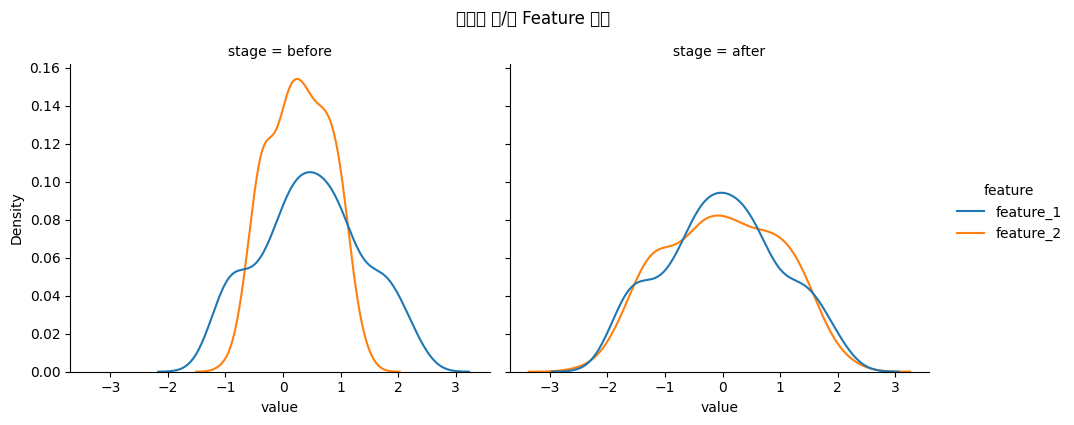

In [10]:
# 9. 표준화 전/후 분포 비교
viz_before = pd.DataFrame({
    "value": np.r_[X_train[:,0], X_train[:,1]],
    "feature": ["feature_1"]*len(X_train) + ["feature_2"]*len(X_train),
    "stage": "before"
})
viz_after = pd.DataFrame({
    "value": np.r_[X_train_s[:,0], X_train_s[:,1]],
    "feature": ["feature_1"]*len(X_train_s) + ["feature_2"]*len(X_train_s),
    "stage": "after"
})
viz_scale = pd.concat([viz_before, viz_after], ignore_index=True)

g = sns.displot(
    data=viz_scale, x="value", hue="feature", col="stage",
    kind="kde", fill=False, height=4, aspect=1.2
)
g.fig.suptitle("표준화 전/후 Feature 분포", y=1.05)
plt.show()

In [11]:
# 10. TensorDataset / DataLoader
def to_loader(X_arr, y_arr, batch_size=32, shuffle=False):
    X_t = torch.tensor(X_arr, dtype=torch.float32)
    y_t = torch.tensor(y_arr, dtype=torch.float32)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train_s, y_train, batch_size=32, shuffle=True)
valid_loader = to_loader(X_valid_s, y_valid, batch_size=64, shuffle=False)
test_loader  = to_loader(X_test_s,  y_test,  batch_size=64, shuffle=False)

xb, yb = next(iter(train_loader))
print("한 배치 X shape:", xb.shape)
print("한 배치 y shape:", yb.shape)
print("첫 3개 X:\n", xb[:3])
print("첫 3개 y:", yb[:3])

한 배치 X shape: torch.Size([32, 2])
한 배치 y shape: torch.Size([32])
첫 3개 X:
 tensor([[-1.8866,  0.3946],
        [ 1.5149, -0.4900],
        [-0.1815, -0.7216]])
첫 3개 y: tensor([0., 1., 1.])


## 배치가 의미하는 것

전체 420개 학습 샘플을 한 번에 처리할 수도 있지만, DataLoader가 32개씩 나누면:

```text
420개 데이터
  ↓
32개
32개
32개
...
마지막 작은 배치
```

각 배치마다:

```text
forward
→ loss
→ backward
→ optimizer.step()
```

가 한 번 실행됨.

**Epoch**는 전체 학습 데이터를 한 바퀴 사용한 횟수임.

`batch_size=32`이고 학습 데이터가 420개라면 대략 한 epoch에 14번의 파라미터 업데이트가 발생함.

# Part 6. Perceptron baseline과 MLP를 같은 조건에서 비교

Top-Down 질문:

> 비선형 데이터에서 MLP가 실제로 무엇을 더 잘하는가?

비교 모델:

### Perceptron에 가까운 선형 모델

```text
2 input → Linear(2,1)
```

### MLP

```text
2 → 8 → ReLU → 8 → ReLU → 1
```

같은 데이터, 같은 loss, 같은 optimizer 계열로 비교함.

In [12]:
# 11. 두 모델 정의
class LinearBinary(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(2, 1)
    def forward(self, x):
        return self.fc(x).squeeze(1)

class MLPBinary(nn.Module):
    def __init__(self, hidden=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

def train_binary(model, train_loader, valid_loader, epochs=120, lr=0.01):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    hist = []

    for epoch in range(1, epochs+1):
        model.train()
        tr_loss = 0.0
        tr_correct = 0
        tr_total = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            opt.step()

            tr_loss += loss.item() * len(xb)
            pred = (logits >= 0).long()
            tr_correct += (pred == yb.long()).sum().item()
            tr_total += len(xb)

        model.eval()
        va_loss = 0.0
        va_correct = 0
        va_total = 0
        with torch.no_grad():
            for xb, yb in valid_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                va_loss += loss.item() * len(xb)
                pred = (logits >= 0).long()
                va_correct += (pred == yb.long()).sum().item()
                va_total += len(xb)

        hist.append({
            "epoch": epoch,
            "train_loss": tr_loss/tr_total,
            "train_acc": tr_correct/tr_total,
            "valid_loss": va_loss/va_total,
            "valid_acc": va_correct/va_total,
        })
    return model, pd.DataFrame(hist)

linear_model, linear_hist = train_binary(LinearBinary(), train_loader, valid_loader)
mlp_model, mlp_hist = train_binary(MLPBinary(hidden=8), train_loader, valid_loader)

print("Linear final valid acc:", linear_hist.iloc[-1]["valid_acc"])
print("MLP    final valid acc:", mlp_hist.iloc[-1]["valid_acc"])

Linear final valid acc: 0.8777777777777778
MLP    final valid acc: 0.9777777777777777


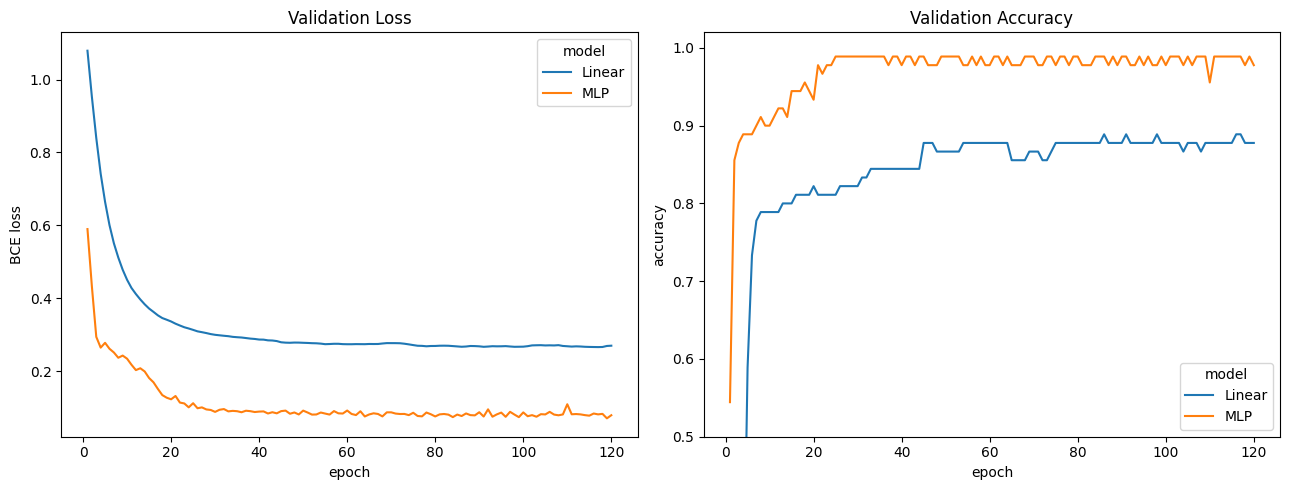

In [13]:
# 12. 학습 곡선 비교
plot_hist = pd.concat([
    linear_hist.assign(model="Linear"),
    mlp_hist.assign(model="MLP")
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.lineplot(data=plot_hist, x="epoch", y="valid_loss", hue="model", ax=axes[0])
axes[0].set_title("Validation Loss")
axes[0].set_ylabel("BCE loss")

sns.lineplot(data=plot_hist, x="epoch", y="valid_acc", hue="model", ax=axes[1])
axes[1].set_title("Validation Accuracy")
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(0.5, 1.02)

plt.tight_layout()
plt.show()

## 그래프 해석

- **Loss**: 모델이 정답에 얼마나 잘 맞는 확률을 내놓는지 반영
- **Accuracy**: 최종 class 판단이 맞았는지의 비율
- Accuracy는 같아도 loss는 다를 수 있음

예:

```text
정답 = 1
모델 A 확률 = 0.51 → 맞음
모델 B 확률 = 0.99 → 맞음
```

둘 다 accuracy에는 1회 정답으로 동일하지만 BCE loss는 B가 훨씬 작음.

따라서 학습에서는 단순 정답 개수보다 **연속적으로 미분 가능한 loss**가 필요함.

/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51649 (\N{HANGUL SYLLABLE JIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw

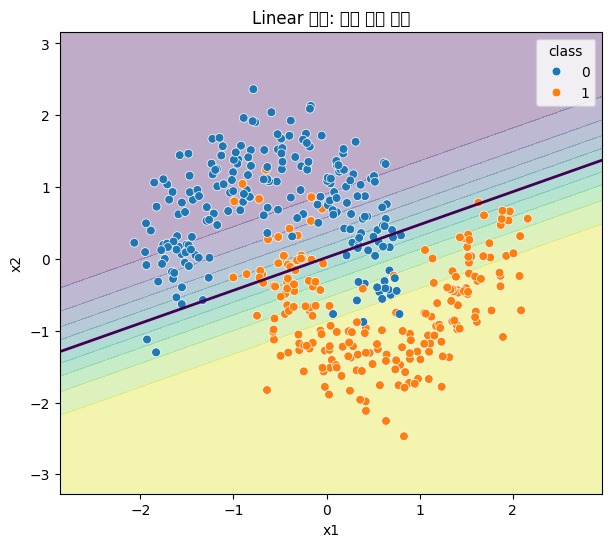

/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io,

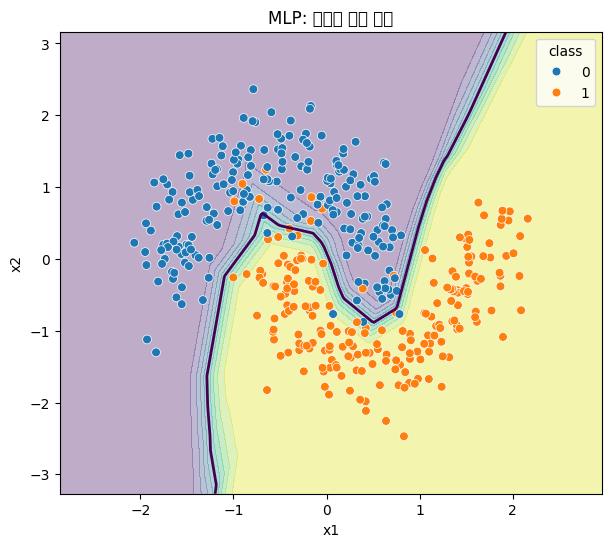

In [14]:
# 13. 결정 경계 시각화
def decision_surface(model, X_scaled, y_data, title):
    x1_min, x1_max = X_scaled[:,0].min()-0.8, X_scaled[:,0].max()+0.8
    x2_min, x2_max = X_scaled[:,1].min()-0.8, X_scaled[:,1].max()+0.8
    xx, yy = np.meshgrid(
        np.linspace(x1_min, x1_max, 260),
        np.linspace(x2_min, x2_max, 260)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    with torch.no_grad():
        logits = model(torch.tensor(grid, dtype=torch.float32, device=DEVICE))
        probs = torch.sigmoid(logits).cpu().numpy().reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, probs, levels=np.linspace(0,1,11), alpha=0.35)
    plt.contour(xx, yy, probs, levels=[0.5], linewidths=2)
    df = pd.DataFrame(X_scaled, columns=["x1","x2"])
    df["class"] = y_data
    sns.scatterplot(data=df, x="x1", y="x2", hue="class", s=40)
    plt.title(title)
    plt.show()

decision_surface(linear_model, X_train_s, y_train, "Linear 모델: 직선 결정 경계")
decision_surface(mlp_model, X_train_s, y_train, "MLP: 비선형 결정 경계")

## 가장 중요한 시각적 결론

Linear 모델의 `z=0` 경계는 직선임.

MLP에서는 여러 은닉 뉴런이 서로 다른 선형 변환을 만들고 ReLU가 영역별로 활성/비활성을 바꿈. 그 결과 최종 출력은 여러 **piecewise-linear 영역**의 조합이 되어 꺾인 경계를 표현 가능함.

“MLP가 선을 실제 곡선 함수로 직접 그린다”라고 이해하기보다는:

> 여러 선형 조각을 비선형 활성화로 조합해 복잡한 경계를 근사한다

가 더 정확함.

# Part 7. 은닉 뉴런은 무엇을 보고 있는가?

MLP의 첫 번째 은닉층에는 8개 뉴런이 있음.

각 뉴런:

\[
z_j=w_{j1}x_1+w_{j2}x_2+b_j
\]

\[
a_j=\max(0,z_j)
\]

즉 각 뉴런은 입력 평면에서 자기만의 선형 경계를 가지고 한쪽 영역에서 주로 활성화됨.

이를 실제 학습된 MLP에서 시각화함.

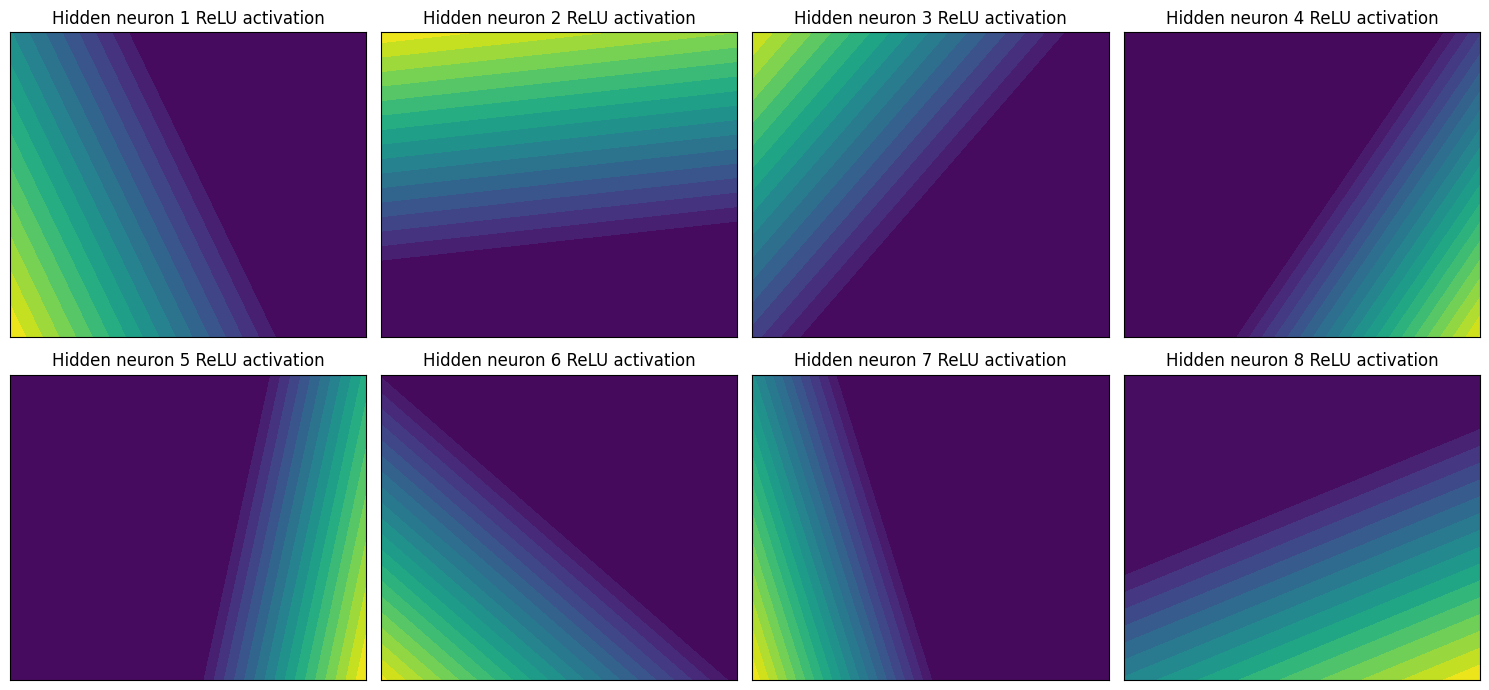

In [15]:
# 14. 첫 은닉층 activation map
mlp_model.eval()
first_linear = mlp_model.net[0]

x1_min, x1_max = X_train_s[:,0].min()-0.6, X_train_s[:,0].max()+0.6
x2_min, x2_max = X_train_s[:,1].min()-0.6, X_train_s[:,1].max()+0.6
xx, yy = np.meshgrid(np.linspace(x1_min,x1_max,180), np.linspace(x2_min,x2_max,180))
grid = np.c_[xx.ravel(), yy.ravel()]

with torch.no_grad():
    z = first_linear(torch.tensor(grid, dtype=torch.float32, device=DEVICE))
    a = torch.relu(z).cpu().numpy()

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for j, ax in enumerate(axes.flat):
    contour = ax.contourf(xx, yy, a[:,j].reshape(xx.shape), levels=20)
    ax.set_title(f"Hidden neuron {j+1} ReLU activation")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

,feature_1 weight,feature_2 weight,bias
h1,-1.5787,-0.5860,0.7751
h2,-0.0994,0.6973,1.0099
h3,-0.6762,0.4517,0.2665
h4,1.2905,-0.6763,-0.6057
h5,1.6184,-0.2725,-1.0557
h6,-0.9161,-0.8080,0.1558
h7,-1.4483,-0.3509,-0.7848
h8,0.6424,-1.2026,0.8900


/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52395 (\N{HANGUL SYLLABLE CEOS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45769 (\N{HANGUL SYLLABLE NIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52789 (\N{HANGUL SYLLABLE CEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

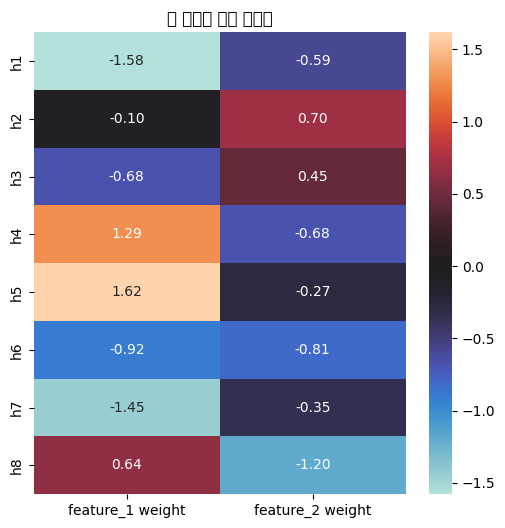

In [16]:
# 15. 첫 번째 층 weight heatmap
W = first_linear.weight.detach().cpu().numpy()
b = first_linear.bias.detach().cpu().numpy()

w_df = pd.DataFrame(W, columns=["feature_1 weight", "feature_2 weight"],
                    index=[f"h{i+1}" for i in range(W.shape[0])])
display(w_df.assign(bias=b))

plt.figure(figsize=(6, 6))
sns.heatmap(w_df, annot=True, fmt=".2f", center=0)
plt.title("첫 은닉층 학습 가중치")
plt.show()

## Weight를 어떻게 읽을까?

예를 들어 특정 은닉 뉴런의 가중치가:

```text
feature_1: +1.5
feature_2: -0.4
bias    : +0.2
```

라면 대략:

\[
z=1.5x_1-0.4x_2+0.2
\]

를 계산함.

단, **은닉 뉴런 하나의 가중치를 곧바로 “feature_1이 전체 모델에서 1.5만큼 중요하다”라고 해석하면 안 됨**.

이유:

- 뒤에 다른 은닉층이 존재
- ReLU로 활성 여부가 샘플마다 달라짐
- 다음 층 가중치와 조합되어 최종 결과가 만들어짐

즉 선형회귀의 회귀계수처럼 직접적인 전역 해석이 어려움.

# Part 8. 학습 루프를 한 줄씩 의미로 읽기

제공 자료의 핵심 학습 순서:

```python
model.train()

for xb, yb in loader:
    xb, yb = xb.to(device), yb.to(device)

    logits = model(xb)          # 1. 순전파
    optimizer.zero_grad()       # 2. 이전 gradient 제거
    loss = criterion(logits,yb) # 3. 오차 측정
    loss.backward()             # 4. gradient 계산
    optimizer.step()            # 5. parameter 업데이트
```

## 왜 `zero_grad()`가 필요한가?

PyTorch는 기본적으로 gradient를 **누적(accumulate)**함.

두 번 backward하면:

```text
현재 grad = 이전 grad + 새 grad
```

일반적인 mini-batch 학습에서는 각 배치의 gradient로 한 번 업데이트하려 하므로 매 배치마다 지움.

## 왜 `model.train()` / `model.eval()`이 필요한가?

Dropout/BatchNorm이 모드에 따라 다르게 동작하기 때문.

- `train()` → Dropout 활성
- `eval()` → Dropout 비활성

제공 MLP 실습의 3-layer 모델은 Dropout을 사용하므로 특히 중요함.

# Part 9. Dropout을 눈으로 확인

Dropout은 학습 중 일부 activation을 확률적으로 0으로 만들어 특정 뉴런 조합에 지나치게 의존하는 현상을 줄임.

평가에서는 모든 뉴런을 사용함.

아래에서 **같은 입력**을 여러 번 넣어도 `train()`에서는 결과가 달라지고, `eval()`에서는 동일한 결과가 나오는 것을 확인함.

In [17]:
# 16. Dropout 동작 실험
drop_demo = nn.Sequential(
    nn.Linear(2, 6),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(6, 1)
)

sample = torch.tensor([[0.5, -0.2]], dtype=torch.float32)

drop_demo.train()
train_outputs = [drop_demo(sample).item() for _ in range(6)]

drop_demo.eval()
eval_outputs = [drop_demo(sample).item() for _ in range(6)]

print("train() 출력:", np.round(train_outputs, 4))
print("eval() 출력 :", np.round(eval_outputs, 4))

train() 출력: [-0.225  -0.1071 -0.0439 -0.1071 -0.0439 -0.2584]
eval() 출력 : [-0.2101 -0.2101 -0.2101 -0.2101 -0.2101 -0.2101]


# Part 10. 실제 샘플 문제 — 8×8 손글씨 숫자 분류

제공 MLP 실습은 `sklearn.datasets.load_digits`를 사용함.

- 샘플 수: 약 1,800개
- 입력: 8×8 grayscale 이미지
- MLP에 넣기 위해 64개 숫자로 펼침
- 출력 class: 0~9, 총 10개

이제 앞에서 배운 구조를 그대로 확장함.

```text
64 features
   ↓
Linear(64 → 128)
   ↓
ReLU
   ↓
Dropout
   ↓
Linear(128 → 64)
   ↓
ReLU
   ↓
Dropout
   ↓
Linear(64 → 10)
   ↓
10개 logits
   ↓
CrossEntropyLoss
```

/tmp/ipykernel_711/1419007568.py:17: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_711/1419007568.py:17: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


X shape: (1797, 64)
y shape: (1797,)
pixel min/max: 0.0 16.0


/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


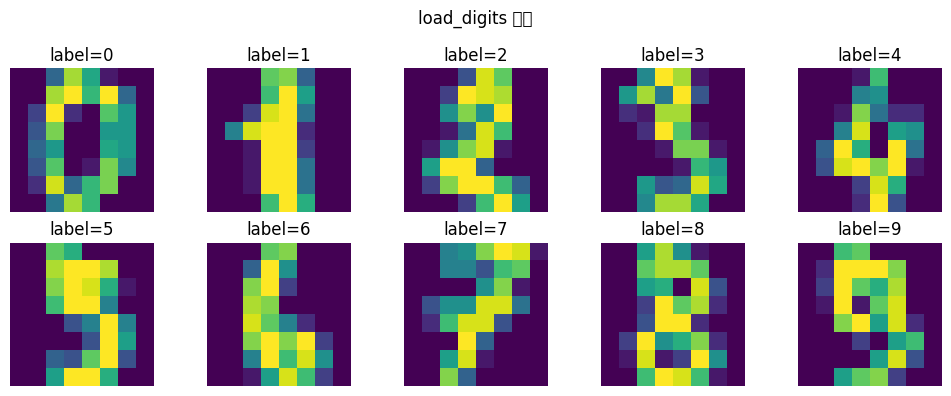

In [18]:
# 17. digits 데이터 확인
digits = load_digits()
Xd = digits.data.astype(np.float32)
yd = digits.target.astype(np.int64)

print("X shape:", Xd.shape)
print("y shape:", yd.shape)
print("pixel min/max:", Xd.min(), Xd.max())

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for cls, ax in enumerate(axes.flat):
    idx = np.where(yd == cls)[0][0]
    ax.imshow(Xd[idx].reshape(8,8))
    ax.set_title(f"label={cls}")
    ax.axis("off")
plt.suptitle("load_digits 샘플")
plt.tight_layout()
plt.show()

,digit,count
0,0,178
1,1,182
2,2,177
3,3,183
4,4,181
5,5,182
6,6,181
7,7,179
8,8,174
9,9,180


/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

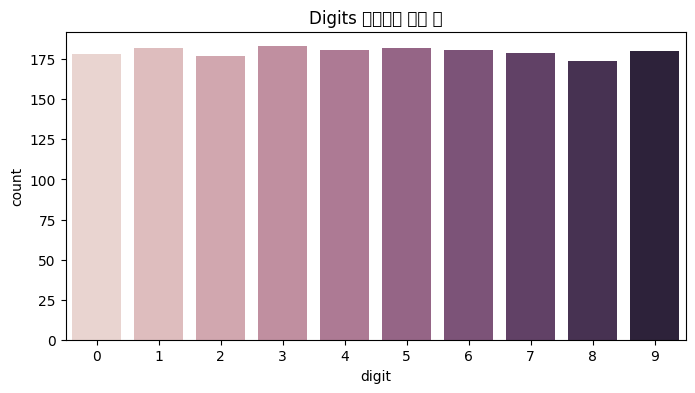

In [19]:
# 18. 클래스 분포
class_counts = pd.Series(yd).value_counts().sort_index().rename_axis("digit").reset_index(name="count")
display(class_counts)

plt.figure(figsize=(8,4))
sns.barplot(data=class_counts, x="digit", y="count", hue="digit", legend=False)
plt.title("Digits 클래스별 샘플 수")
plt.show()

## 64개 Feature는 무엇인가?

8×8 이미지:

\[
8\times8=64
\]

각 픽셀 밝기가 하나의 Feature임.

```text
2D 이미지
[8,8]
  ↓ flatten
[64]
  ↓ Linear
[128]
```

MLP는 이미지의 2차원 공간 구조를 직접 이용하지 않고 일렬로 펼친 64차원 벡터로 처리함.

이 때문에 이미지에서는 CNN이 더 적합한 경우가 많지만, **신경망 기본 원리 학습**에는 작은 MLP가 적합함.

In [20]:
# 19. digits 분할/표준화
Xd_train, Xd_temp, yd_train, yd_temp = train_test_split(
    Xd, yd, test_size=0.20, random_state=SEED, stratify=yd
)
Xd_valid, Xd_test, yd_valid, yd_test = train_test_split(
    Xd_temp, yd_temp, test_size=0.50, random_state=SEED, stratify=yd_temp
)

digit_scaler = StandardScaler()
Xd_train_s = digit_scaler.fit_transform(Xd_train).astype(np.float32)
Xd_valid_s = digit_scaler.transform(Xd_valid).astype(np.float32)
Xd_test_s = digit_scaler.transform(Xd_test).astype(np.float32)

def multiclass_loader(X_arr, y_arr, batch_size=64, shuffle=False):
    ds = TensorDataset(
        torch.tensor(X_arr, dtype=torch.float32),
        torch.tensor(y_arr, dtype=torch.long)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

dtrain_loader = multiclass_loader(Xd_train_s, yd_train, shuffle=True)
dvalid_loader = multiclass_loader(Xd_valid_s, yd_valid)
dtest_loader = multiclass_loader(Xd_test_s, yd_test)

print(len(Xd_train_s), len(Xd_valid_s), len(Xd_test_s))

1437 180 180


# Part 11. 다중 클래스에서는 왜 출력이 10개인가?

숫자 0~9 각각에 대한 **logit 10개**를 출력함.

예:

```text
class 0 logit: -1.2
class 1 logit:  0.4
class 2 logit:  3.8   ← 가장 큼
...
class 9 logit: -0.7
```

예측:

```python
pred = logits.argmax(dim=1)
```

즉 가장 큰 logit의 class index 선택.

---

## Softmax

\[
p_k=\frac{e^{z_k}}{\sum_j e^{z_j}}
\]

10개 logit을 10개 확률로 변환하고 전체 합을 1로 만듦.

`CrossEntropyLoss`는 PyTorch에서 **raw logits**를 입력받아 내부적으로 `log_softmax + NLLLoss`에 해당하는 계산을 안정적으로 처리함.

따라서 모델 끝에 `Softmax`를 별도로 붙이지 않는 것이 일반적임.

In [21]:
# 20. softmax 한 샘플
example_logits = torch.tensor([[0.3, -0.5, 2.1, 0.7]])
example_prob = torch.softmax(example_logits, dim=1)

prob_df = pd.DataFrame({
    "class": [0,1,2,3],
    "logit": example_logits.numpy().ravel(),
    "softmax_probability": example_prob.numpy().ravel()
})
display(prob_df)
print("확률 합:", example_prob.sum().item())
print("예측 class:", example_logits.argmax(dim=1).item())

,class,logit,softmax_probability
0,0,0.3,0.1112
1,1,-0.5,0.0500
2,2,2.1,0.6729
3,3,0.7,0.1659


확률 합: 0.9999998807907104
예측 class: 2


## Cross Entropy의 의미

정답 class가 \(t\)라면:

\[
L=-\log(p_t)
\]

즉 **정답 class에 준 확률만** 직접적으로 읽으면 됨.

- 정답 확률 0.99 → loss 작음
- 정답 확률 0.50 → loss 중간
- 정답 확률 0.01 → loss 매우 큼

모델이 틀렸을 뿐 아니라 **자신 있게 틀린 경우** 더 큰 패널티를 줌.

/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw

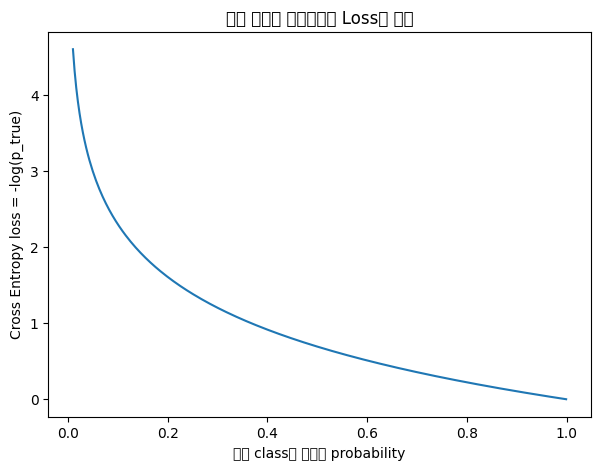

In [22]:
# 21. 정답 확률과 CE loss 관계
pt = np.linspace(0.01, 0.999, 300)
ce = -np.log(pt)
plt.figure(figsize=(7,5))
sns.lineplot(x=pt, y=ce)
plt.xlabel("정답 class에 할당한 probability")
plt.ylabel("Cross Entropy loss = -log(p_true)")
plt.title("정답 확률이 높아질수록 Loss는 감소")
plt.show()

# Part 12. 제공 실습 구조와 동일한 3-layer MLP 구현

제공 MLP 실습의 구조를 따름.

```text
64
 ↓
128 + ReLU + Dropout
 ↓
64 + ReLU + Dropout
 ↓
10 logits
```

In [23]:
# 22. Digits MLP
class DigitsMLP(nn.Module):
    def __init__(self, input_dim=64, num_classes=10, hidden_dims=(128,64), dropout=0.2):
        super().__init__()
        h1, h2 = hidden_dims
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h2, num_classes)
        )
    def forward(self, x):
        return self.net(x)

digits_model = DigitsMLP().to(DEVICE)
print(digits_model)

n_params = sum(p.numel() for p in digits_model.parameters() if p.requires_grad)
print("\n학습 가능한 parameter 수:", n_params)

DigitsMLP(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)

학습 가능한 parameter 수: 17226


## 파라미터 수를 직접 계산하기

### 첫 층 `Linear(64,128)`

Weight:

\[
128\times64=8192
\]

Bias:

\[
128
\]

합:

\[
8320
\]

### 두 번째 `Linear(128,64)`

\[
64\times128+64=8256
\]

### 출력층 `Linear(64,10)`

\[
10\times64+10=650
\]

전체:

\[
8320+8256+650=17226
\]

ReLU와 Dropout에는 학습되는 weight/bias가 없음.

In [24]:
# 23. 한 배치가 층을 통과하면서 shape가 어떻게 바뀌는지 확인
xb, yb = next(iter(dtrain_loader))
xb = xb.to(DEVICE)

layer_outputs = []
h = xb
for i, layer in enumerate(digits_model.net):
    h = layer(h)
    layer_outputs.append((i, layer.__class__.__name__, tuple(h.shape)))

pd.DataFrame(layer_outputs, columns=["index","layer","output shape"])

,index,layer,output shape
0,0,Linear,"(64, 128)"
1,1,ReLU,"(64, 128)"
2,2,Dropout,"(64, 128)"
3,3,Linear,"(64, 64)"
4,4,ReLU,"(64, 64)"
5,5,Dropout,"(64, 64)"
6,6,Linear,"(64, 10)"


# Part 13. 실제 학습 — Adam + Early Stopping

제공 실습에서 사용한 핵심 요소:

- optimizer: `Adam`
- loss: `CrossEntropyLoss`
- validation 성능 관찰
- `model.train()` / `model.eval()`
- Early Stopping
- best checkpoint 개념

여기서는 HTML에서도 결과를 그대로 볼 수 있도록 메모리에서 best state를 보관함.

In [25]:
# 24. train/evaluate 함수
def train_multiclass_epoch(model, loader, optimizer):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = torch.nn.functional.cross_entropy(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(xb)
        total_correct += (logits.argmax(1) == yb).sum().item()
        total += len(xb)

    return total_loss/total, total_correct/total

def eval_multiclass(model, loader):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    preds, targets = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = torch.nn.functional.cross_entropy(logits, yb)

            total_loss += loss.item() * len(xb)
            total_correct += (logits.argmax(1) == yb).sum().item()
            total += len(xb)
            preds.append(logits.argmax(1).cpu())
            targets.append(yb.cpu())

    return (
        total_loss/total,
        total_correct/total,
        torch.cat(preds).numpy(),
        torch.cat(targets).numpy()
    )

In [26]:
# 25. 학습 실행
digits_model = DigitsMLP().to(DEVICE)
optimizer = torch.optim.Adam(digits_model.parameters(), lr=1e-3, weight_decay=1e-4)

best_val_loss = float("inf")
best_state = None
patience = 6
no_improve = 0
history = []

for epoch in range(1, 61):
    train_loss, train_acc = train_multiclass_epoch(digits_model, dtrain_loader, optimizer)
    valid_loss, valid_acc, _, _ = eval_multiclass(digits_model, dvalid_loader)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "valid_loss": valid_loss,
        "train_acc": train_acc,
        "valid_acc": valid_acc
    })

    if valid_loss < best_val_loss - 1e-5:
        best_val_loss = valid_loss
        best_state = {k: v.detach().cpu().clone() for k,v in digits_model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= patience:
        print("Early stopping at epoch", epoch)
        break

history = pd.DataFrame(history)
digits_model.load_state_dict(best_state)

test_loss, test_acc, test_pred, test_true = eval_multiclass(digits_model, dtest_loader)

print("Best validation loss:", best_val_loss)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)
display(history.tail())

Early stopping at epoch 47
Best validation loss: 0.0454250772173206
Test loss: 0.10378273005286852
Test accuracy: 0.9833333333333333


,epoch,train_loss,valid_loss,train_acc,valid_acc
42,43,0.0120,0.0507,0.9972,0.9833
43,44,0.0119,0.0542,0.9993,0.9778
44,45,0.0080,0.0510,0.9986,0.9833
45,46,0.0156,0.0562,0.9965,0.9778
46,47,0.0129,0.0564,0.9958,0.9778


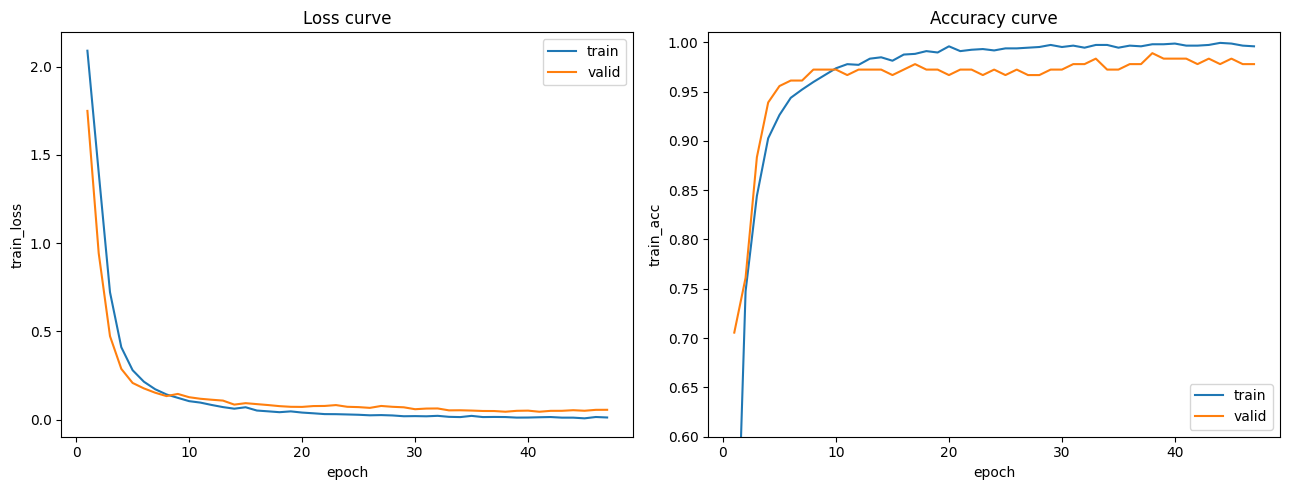

In [27]:
# 26. 학습 곡선
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.lineplot(data=history, x="epoch", y="train_loss", label="train", ax=axes[0])
sns.lineplot(data=history, x="epoch", y="valid_loss", label="valid", ax=axes[0])
axes[0].set_title("Loss curve")

sns.lineplot(data=history, x="epoch", y="train_acc", label="train", ax=axes[1])
sns.lineplot(data=history, x="epoch", y="valid_acc", label="valid", ax=axes[1])
axes[1].set_title("Accuracy curve")
axes[1].set_ylim(0.6, 1.01)

plt.tight_layout()
plt.show()

## 학습 곡선에서 읽어야 하는 패턴

### 정상 학습

```text
train loss ↓
valid loss ↓
```

### 과적합 가능성

```text
train loss 계속 ↓
valid loss 다시 ↑
```

학습 데이터에는 더 잘 맞지만 새로운 데이터 일반화가 나빠지는 상태임.

Early Stopping은 validation loss가 일정 기간 개선되지 않으면 학습을 멈춰 과도한 학습을 방지하는 방법임.

Dropout, weight decay 역시 일반화에 도움을 주는 정규화 수단임.

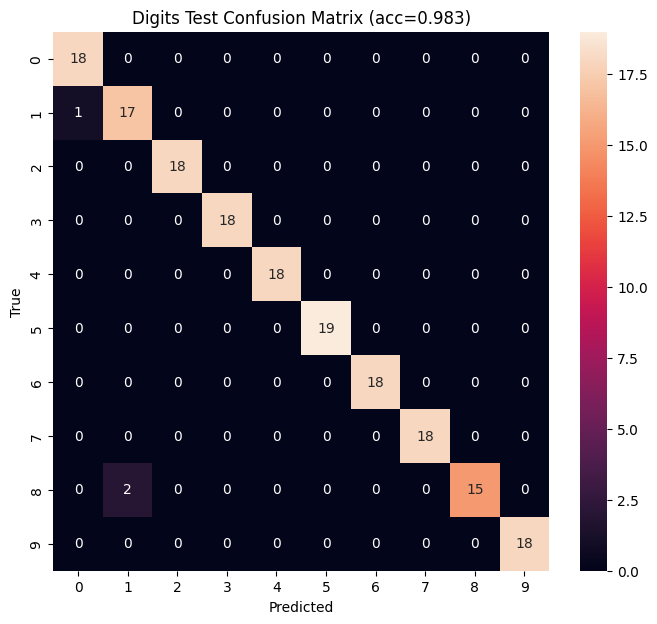

In [28]:
# 27. Confusion Matrix
cm = confusion_matrix(test_true, test_pred)

plt.figure(figsize=(8,7))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Digits Test Confusion Matrix (acc={test_acc:.3f})")
plt.show()

## Confusion Matrix 해석

행 = 실제 정답  
열 = 모델 예측

대각선이 크면 정답을 많이 맞춘 것임.

예를 들어 `(8행, 3열)` 값이 크다면:

> 실제 숫자 8을 모델이 3으로 자주 오해

했다는 뜻임.

Accuracy 하나만으로는 알 수 없는 **어떤 클래스끼리 헷갈리는가**를 분석할 수 있음.

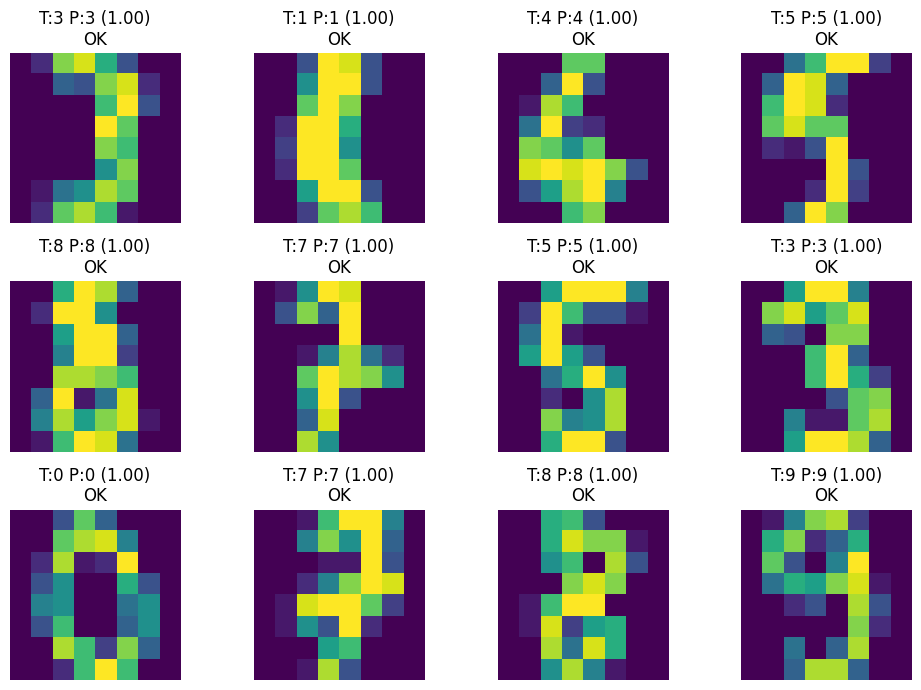

In [29]:
# 28. 샘플별 예측 확률 확인
digits_model.eval()
indices = np.arange(min(12, len(Xd_test_s)))
x_sample = torch.tensor(Xd_test_s[indices], dtype=torch.float32, device=DEVICE)

with torch.no_grad():
    logits = digits_model(x_sample)
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    preds = probs.argmax(1)

fig, axes = plt.subplots(3, 4, figsize=(10, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(Xd_test[indices[i]].reshape(8,8))
    conf = probs[i, preds[i]]
    ok = preds[i] == yd_test[indices[i]]
    ax.set_title(f"T:{yd_test[indices[i]]} P:{preds[i]} ({conf:.2f})\n{'OK' if ok else 'WRONG'}")
    ax.axis("off")
plt.tight_layout()
plt.show()

/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw

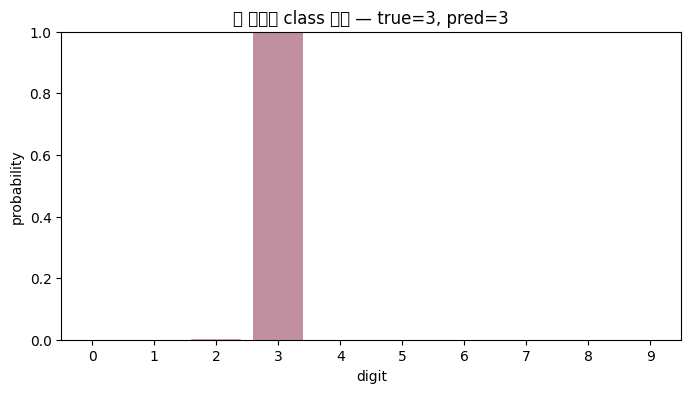

,digit,probability
3,3,9.9806e-01
2,2,1.7272e-03
7,7,1.6389e-04
9,9,3.8459e-05
5,5,6.6637e-06


In [30]:
# 29. 한 샘플의 10개 class probability 막대그래프
i = 0
prob_one = pd.DataFrame({
    "digit": np.arange(10),
    "probability": probs[i]
})

plt.figure(figsize=(8,4))
sns.barplot(data=prob_one, x="digit", y="probability", hue="digit", legend=False)
plt.title(f"한 샘플의 class 확률 — true={yd_test[indices[i]]}, pred={preds[i]}")
plt.ylim(0,1)
plt.show()

display(prob_one.sort_values("probability", ascending=False).head())

# Part 14. MLP를 “계산 그래프”로 다시 요약

## 이진 분류

```text
x
↓
Linear: z1 = W1x + b1
↓
ReLU: a1 = max(0,z1)
↓
Linear
↓
ReLU
↓
Linear
↓
logit
↓
BCEWithLogitsLoss
↓
loss
↓
backward
↓
각 W,b의 gradient
↓
Adam / SGD
↓
새 W,b
```

## 다중 분류

```text
64 pixel features
↓
hidden representation
↓
10 logits
↓
CrossEntropyLoss
↓
gradient
↓
parameter update
```

---

# Part 15. 각 개념의 역할을 한 문장으로

| 개념 | 역할 |
|---|---|
| Tensor | 숫자 데이터를 PyTorch 연산 단위로 표현 |
| Linear | \(Wx+b\)로 Feature를 새로운 표현으로 변환 |
| Weight | 입력 신호를 얼마나 강하게 반영할지 결정 |
| Bias | 뉴런의 활성 기준을 이동 |
| ReLU | 비선형성을 추가하여 복잡한 패턴 표현 가능 |
| Logit | 확률 변환 전 모델의 원시 점수 |
| Sigmoid | 이진 logit을 0~1로 변환 |
| Softmax | 다중 class logits를 합이 1인 분포로 변환 |
| Loss | 현재 예측이 얼마나 나쁜지 수치화 |
| Gradient | parameter를 조금 바꿀 때 loss가 변하는 방향/크기 |
| Backpropagation | chain rule로 모든 parameter의 gradient 계산 |
| Optimizer | gradient를 사용해 parameter 실제 업데이트 |
| Batch | 한 번의 update에 사용하는 샘플 묶음 |
| Epoch | 전체 training set을 한 번 사용 |
| Validation | 학습 중 일반화 상태를 관찰 |
| Test | 최종 모델의 새로운 데이터 성능 측정 |
| Dropout | 학습 중 일부 activation을 제거해 과적합 완화 |
| Early Stopping | validation 개선이 멈추면 학습 종료 |

---

# Part 16. 지식 노드 연결

```text
[선형회귀의 Wx+b]
      ↓ 같은 선형 계산
[Perceptron]
      ↓ 비선형 문제의 한계
[ReLU / 활성화 함수]
      ↓ 함수 중첩
[MLP]
      ↓ 예측과 정답 비교
[Loss]
      ↓ 미분
[Gradient]
      ↓ chain rule
[Backpropagation]
      ↓ 업데이트
[Optimizer]
      ↓ 반복
[Training Loop]
      ↓ 일반화 확인
[Validation / Test]
```

---

# Part 17. 자가 점검 문제

### Q1
`Linear(64, 128)`의 weight shape와 bias shape는?

### Q2
`Linear → Linear` 사이에 활성화 함수가 없으면 왜 깊게 쌓아도 표현력이 제한되는가?

### Q3
ReLU 입력값이 음수일 때 해당 지점의 derivative는 일반적으로 얼마로 처리되는가?

### Q4
이진 분류에서 logit이 0이면 sigmoid 확률은?

### Q5
`optimizer.zero_grad()`를 하지 않으면 무슨 일이 발생하는가?

### Q6
왜 validation/test 데이터에 `scaler.fit()`을 하면 안 되는가?

### Q7
10-class 분류 모델의 마지막 Linear 출력 차원은 왜 10인가?

### Q8
`CrossEntropyLoss` 전에 모델에 Softmax를 붙이지 않는 이유는?

### Q9
`model.eval()`이 특히 Dropout 모델에서 중요한 이유는?

### Q10
train loss는 계속 감소하지만 validation loss가 증가하기 시작하면 무엇을 의심해야 하는가?

---

## 정답

1. weight `(128,64)`, bias `(128,)`
2. 선형함수의 합성은 다시 선형함수로 합칠 수 있기 때문
3. 0
4. 0.5
5. 이전 batch의 gradient와 새 gradient가 누적됨
6. 미래 데이터 통계가 학습 과정에 들어가는 data leakage 발생
7. 각 class 0~9에 대한 logit 하나씩 필요
8. `CrossEntropyLoss`가 raw logits를 받아 안정적인 log-softmax 계산을 내부 처리
9. train 모드에서는 Dropout이 랜덤하게 뉴런을 끄므로 추론 결과가 흔들릴 수 있음
10. 과적합

---

# 다음 학습 권장 순서

```text
MLP
↓
활성화 함수 비교: ReLU / Sigmoid / Tanh
↓
Optimizer: SGD / Momentum / Adam
↓
초기화: Xavier / He
↓
Batch Normalization
↓
CNN
↓
Attention / Transformer
```